In [1]:
#libraries in medical imaging
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.8 MB/s eta 0:00:00


In [2]:
#loads the DICOM library into Python
import pydicom
#plotting library
import matplotlib.pyplot as plt
#Numpy is the numerical library in Python and stores the CT image numbers
import numpy as np

## Mount Google Drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Create the folder used to save project figures
import os

figures_path = "/content/drive/MyDrive/AI_Medical/COCA/figures"
os.makedirs(figures_path, exist_ok=True)

print("Figures folder:", figures_path)


Figures folder: /content/drive/MyDrive/AI_Medical/COCA/figures


In [5]:
#find thd dataset path
import os

os.listdir("/content/drive/MyDrive")

['Coronary Disease.gdoc',
 'Software_Operation_Manual_SMM-MAE-zh-CN-translation.gdoc',
 'Software Operation Manual.gdoc',
 'ECG Label.gsheet',
 'Heart disease data.gdoc',
 '无标题文档.gdoc',
 'ECG label.gdoc',
 'Binary for heart disease.ipynb',
 '心脏CT_Biomedical_AI项目.gdoc',
 'CT ai.gdoc',
 'AI_Medical',
 'Colab Notebooks',
 'Untitled1.ipynb']

## Inspect Dataset Structure

In [6]:
#get into the AI medical file
os.listdir("/content/drive/MyDrive/AI_Medical")

['COCA']

In [7]:
os.listdir("/content/drive/MyDrive/AI_Medical/COCA/raw_data")

['gated_files']

In [8]:
patient_path = "/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/patient"

import os

print(os.listdir(patient_path)[:10])

['.DS_Store', '135', '307', '763', '551', '61', '95', '338', '556', '764']


In [9]:
#Ignore DS_store
patients = [
    p for p in os.listdir(patient_path) #Show everthing inside the folder
    if not p.startswith(".") #Ignore anything beginning with .(like.DS_store)
]

print(patients[:10])

['135', '307', '763', '551', '61', '95', '338', '556', '764', '300']


In [10]:
patients = [
    p for p in os.listdir(patient_path) #Take one item at a time
    if not p.startswith(".") #Ignore anything beginning with .(like.DS_store)
]

first_patient = patients[0] #First Patient

print(first_patient)

135


In [11]:
dicom_folder = os.path.join(patient_path, first_patient)

print(os.listdir(dicom_folder)[:10])

['Pro_Gated_Calcium_Score_(CS)_3.0_Qr36_2_BestDiast_70_%']


In [12]:
# Create a new varible which store the path to the folder that contains all the DICOM images
scan_folder = os.path.join(
    dicom_folder,
    os.listdir(dicom_folder)[0]#return the first folder
)

print(scan_folder)

/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/patient/135/Pro_Gated_Calcium_Score_(CS)_3.0_Qr36_2_BestDiast_70_%


In [13]:
print(os.listdir(scan_folder)[:10])

['.azDownload-106f050f-1fc2-8547-7741-7bce76d6180a-IM-3678-0024.dcm', 'IM-3678-0044.dcm', 'IM-3678-0016.dcm', 'IM-3678-0008.dcm', 'IM-3678-0032.dcm', 'IM-3678-0003.dcm', 'IM-3678-0022.dcm', 'IM-3678-0011.dcm', 'IM-3678-0005.dcm', 'IM-3678-0017.dcm']


In [14]:
#Keep only files ending with dcm
dicom_files = [
    f for f in os.listdir(scan_folder) # Go through every file
    if f.endswith(".dcm") and not f.startswith(".") # Keep only files ending with.dcm, ignore hidden file
]

print(dicom_files[:10])

['IM-3678-0044.dcm', 'IM-3678-0016.dcm', 'IM-3678-0008.dcm', 'IM-3678-0032.dcm', 'IM-3678-0003.dcm', 'IM-3678-0022.dcm', 'IM-3678-0011.dcm', 'IM-3678-0005.dcm', 'IM-3678-0017.dcm', 'IM-3678-0033.dcm']


In [15]:
print(dicom_files[:20])

['IM-3678-0044.dcm', 'IM-3678-0016.dcm', 'IM-3678-0008.dcm', 'IM-3678-0032.dcm', 'IM-3678-0003.dcm', 'IM-3678-0022.dcm', 'IM-3678-0011.dcm', 'IM-3678-0005.dcm', 'IM-3678-0017.dcm', 'IM-3678-0033.dcm', 'IM-3678-0001.dcm', 'IM-3678-0041.dcm', 'IM-3678-0028.dcm', 'IM-3678-0021.dcm', 'IM-3678-0046.dcm', 'IM-3678-0034.dcm', 'IM-3678-0012.dcm', 'IM-3678-0009.dcm', 'IM-3678-0039.dcm', 'IM-3678-0006.dcm']


## Load a DICOM Slice

In [16]:
#Find one DICOM file
first_dicom = os.path.join(
    scan_folder,
    dicom_files[0]
)

print(first_dicom)

/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/patient/135/Pro_Gated_Calcium_Score_(CS)_3.0_Qr36_2_BestDiast_70_%/IM-3678-0044.dcm


In [17]:
# Read the selected DICOM slice
ds = pydicom.dcmread(first_dicom)

# Extract the original pixel array
image = ds.pixel_array.astype(np.float32)

print("Image shape:", image.shape)
print("Data type:", image.dtype)


Image shape: (512, 512)
Data type: float32


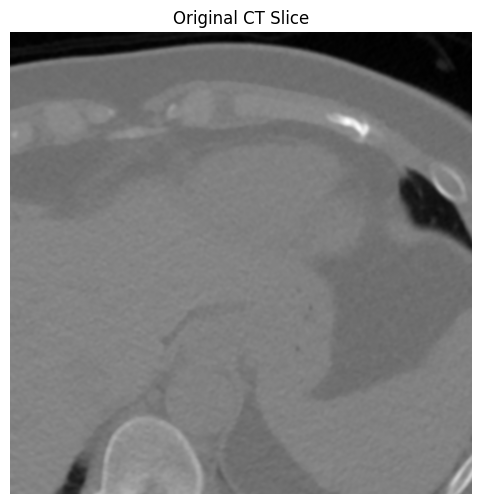

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Original CT Slice")
plt.axis("off")

plt.savefig(
    os.path.join(figures_path, "original_ct.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Convert Pixel Values to HU

In [19]:
#Convert pixels into HU, HU=pixel*1+intercept
slope = float(ds.RescaleSlope)
intercept = float(ds.RescaleIntercept)

print("RescaleSlope:", slope)
print("RescaleIntercept:", intercept)

RescaleSlope: 1.0
RescaleIntercept: -1024.0


In [20]:
image_hu = image.astype(np.float32) * slope + intercept

print("Minimum HU:", image_hu.min())
print("Maximum HU:", image_hu.max())
print("Mean HU:", image_hu.mean())

Minimum HU: -1024.0
Maximum HU: 1082.0
Mean HU: -62.96051


## Apply CT Windowing

In [21]:
# To set the windowing function (shrink the range)
def apply_window(image_hu, window_center, window_width):
    """
    Apply CT windowing.
    """

    lower = window_center - window_width / 2
    upper = window_center + window_width / 2
#Everything outside the window is clipped to the neareast boundary
    windowed = np.clip(image_hu, lower, upper)

    return windowed

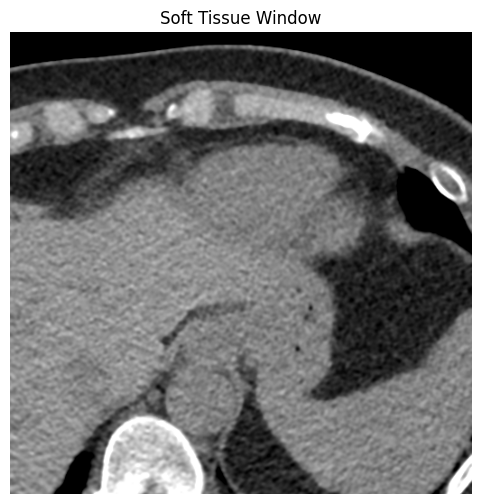

In [22]:
# Show the soft tissue window
windowed_image = apply_window(
    image_hu,
    window_center=40,
    window_width=400
)

plt.figure(figsize=(6, 6))
plt.imshow(windowed_image, cmap="gray")
plt.title("Soft Tissue Window")
plt.axis("off")

plt.savefig(
    os.path.join(figures_path, "soft_tissue_window.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Parse XML Annotations

In [23]:
#To get the XML folder path
xml_path = "/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/calcium_xml"

In [24]:
#Ignore hidden files and list XML files
xml_files = [
    f for f in os.listdir(xml_path)
    if f.endswith(".xml") and not f.startswith(".")
]

print("Number of XML files:", len(xml_files))
print(xml_files[:10])

Number of XML files: 451
['152.xml', '396.xml', '302.xml', '297.xml', '327.xml', '179.xml', '103.xml', '429.xml', '307.xml', '105.xml']


In [25]:
expected_xml = f"{first_patient}.xml"

print("Expected XML:", expected_xml)
print("Does it exist?", expected_xml in xml_files)

Expected XML: 135.xml
Does it exist? True


In [26]:
patient_xml = os.path.join(xml_path, expected_xml)
print(patient_xml)

/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/calcium_xml/135.xml


In [27]:
import plistlib

with open(patient_xml, "rb") as f:
    annotation = plistlib.load(f)

print(type(annotation))
print(annotation.keys())

<class 'dict'>
dict_keys(['Images'])


In [28]:
images_info = annotation["Images"]

print("Number of annotated image entries:", len(images_info))
print(images_info[0].keys())

Number of annotated image entries: 4
dict_keys(['ImageIndex', 'NumberOfROIs', 'ROIs'])


In [29]:
real_rois = []

for image_entry in images_info:
    image_index = image_entry["ImageIndex"]

    for roi in image_entry.get("ROIs", []):
        number_of_points = roi.get("NumberOfPoints", 0)

        if number_of_points > 0:
            real_rois.append({
                "image_index": image_index,
                "name": roi.get("Name", "Unknown"),
                "number_of_points": number_of_points,
                "points_px": roi.get("Point_px", []),
                "area": roi.get("Area", None)
            })

print("Real ROIs found:", len(real_rois))

for roi in real_rois:
    print(roi)

Real ROIs found: 3
{'image_index': 29, 'name': 'Left Circumflex Artery', 'number_of_points': 6, 'points_px': ['(250.003922, 288.000000)', '(250.003922, 289.000000)', '(251.000000, 289.996078)', '(251.996078, 289.000000)', '(251.996078, 288.000000)', '(251.000000, 287.003922)'], 'area': 0.0023365020751953125}
{'image_index': 30, 'name': 'Left Anterior Descending Artery', 'number_of_points': 16, 'points_px': ['(261.003922, 258.000000)', '(261.000000, 258.003922)', '(260.000000, 258.003922)', '(259.003922, 259.000000)', '(259.000000, 259.003922)', '(258.003922, 260.000000)', '(259.000000, 260.996078)', '(260.000000, 260.996078)', '(260.996078, 260.000000)', '(261.000000, 259.996078)', '(262.000000, 259.996078)', '(262.996078, 259.000000)', '(263.000000, 258.996078)', '(263.996078, 258.000000)', '(263.000000, 257.003922)', '(262.000000, 257.003922)'], 'area': 0.008177757263183594}
{'image_index': 30, 'name': 'Left Circumflex Artery', 'number_of_points': 8, 'points_px': ['(249.003922, 287.0

In [30]:
first_real_roi = real_rois[0]

print("Image index:", first_real_roi["image_index"])
print("Artery:", first_real_roi["name"])
print("Number of points:", first_real_roi["number_of_points"])
print("Area:", first_real_roi["area"])
print("Pixel points:")
print(first_real_roi["points_px"])

Image index: 29
Artery: Left Circumflex Artery
Number of points: 6
Area: 0.0023365020751953125
Pixel points:
['(250.003922, 288.000000)', '(250.003922, 289.000000)', '(251.000000, 289.996078)', '(251.996078, 289.000000)', '(251.996078, 288.000000)', '(251.000000, 287.003922)']


## Match XML ImageIndex to DICOM Slice

In [31]:
import re
import numpy as np
from matplotlib.patches import Polygon

# Convert "(250.0, 288.0)" -> [250.0, 288.0]
points = []

for p in first_real_roi["points_px"]:
    nums = re.findall(r"-?\d+\.?\d*", p)
    points.append([float(nums[0]), float(nums[1])])

points = np.array(points)

print(points)

[[250.003922 288.      ]
 [250.003922 289.      ]
 [251.       289.996078]
 [251.996078 289.      ]
 [251.996078 288.      ]
 [251.       287.003922]]


In [32]:
print("Number of points:", len(points))
print(points)

print("Shape:", points.shape)

Number of points: 6
[[250.003922 288.      ]
 [250.003922 289.      ]
 [251.       289.996078]
 [251.996078 289.      ]
 [251.996078 288.      ]
 [251.       287.003922]]
Shape: (6, 2)


In [33]:
# Find the XML entry whose ImageIndex label matches the annotated ROI
target = first_real_roi["image_index"]

target_entry = next(
    entry for entry in images_info
    if entry["ImageIndex"] == target
)

# Find the actual ROI with polygon points inside this image entry
target_roi = next(
    roi for roi in target_entry.get("ROIs", [])
    if roi.get("NumberOfPoints", 0) > 0
)

print("Matched XML ImageIndex:", target_entry["ImageIndex"])
print("Artery:", target_roi.get("Name", "Unknown"))
print("Number of points:", target_roi["NumberOfPoints"])


Matched XML ImageIndex: 29
Artery: Left Circumflex Artery
Number of points: 6


In [34]:
# Get the physical z-position stored in the XML annotation
roi_z = float(
    target_roi["Point_mm"][0]
    .strip("()")
    .split(",")[2]
)

# Find the DICOM slice whose ImagePositionPatient z-value is closest
z_matches = []

for filename in dicom_files:
    path = os.path.join(scan_folder, filename)
    temp_ds = pydicom.dcmread(path, stop_before_pixels=True)

    if hasattr(temp_ds, "ImagePositionPatient"):
        dicom_z = float(temp_ds.ImagePositionPatient[2])

        z_matches.append({
            "filename": filename,
            "instance": int(temp_ds.InstanceNumber),
            "dicom_z": dicom_z,
            "difference": abs(dicom_z - roi_z)
        })

best_match = min(z_matches, key=lambda item: item["difference"])

print("XML ImageIndex:", target_entry["ImageIndex"])
print("XML ROI z-position:", roi_z)
print("Matched filename:", best_match["filename"])
print("InstanceNumber:", best_match["instance"])
print("DICOM z-position:", best_match["dicom_z"])
print("Difference:", best_match["difference"])


XML ImageIndex: 29
XML ROI z-position: -149.5
Matched filename: IM-3678-0017.dcm
InstanceNumber: 17
DICOM z-position: -149.5
Difference: 0.0


In [35]:
matched_path = os.path.join(
    scan_folder,
    best_match["filename"]
)

matched_ds = pydicom.dcmread(matched_path)

matched_image = matched_ds.pixel_array.astype(np.float32)

matched_hu = (
    matched_image
    * float(getattr(matched_ds, "RescaleSlope", 1))
    + float(getattr(matched_ds, "RescaleIntercept", 0))
)

matched_windowed = apply_window(
    matched_hu,
    window_center=40,
    window_width=400
)

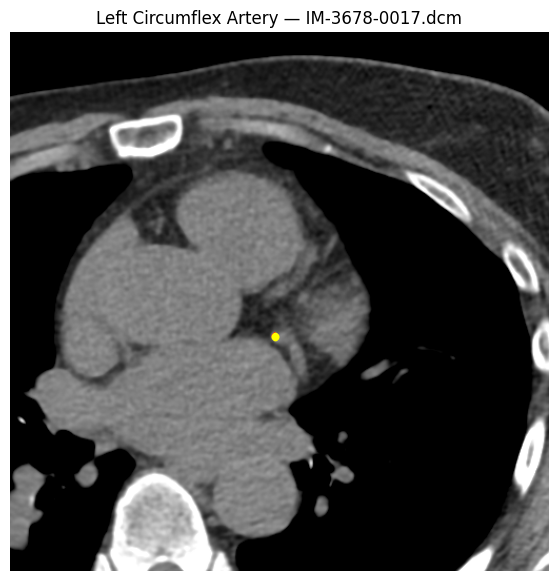

In [36]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(matched_windowed, cmap="gray")

polygon = Polygon(
    points,
    closed=True,
    fill=False,
    edgecolor="red",
    linewidth=3
)

ax.add_patch(polygon)

ax.scatter(
    points[:, 0],
    points[:, 1],
    c="yellow",
    s=10
)

ax.set_title(
    f"{first_real_roi['name']} — {best_match['filename']}"
)
ax.axis("off")

plt.savefig(
    os.path.join(figures_path, "roi_overlay.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


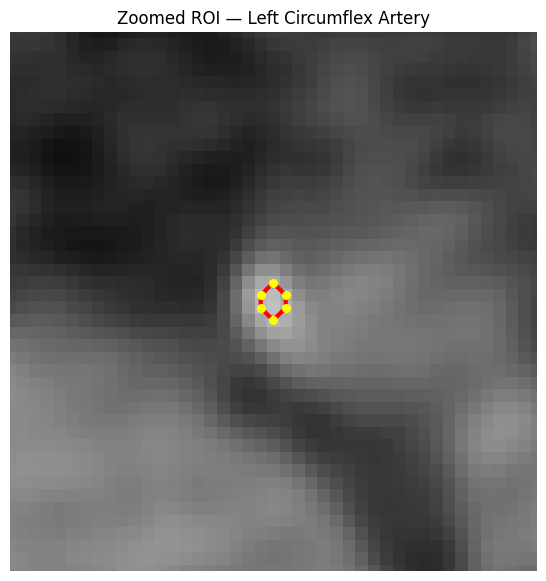

In [37]:
# Zoom in around the small calcium ROI
x_min = int(np.floor(points[:, 0].min()))
x_max = int(np.ceil(points[:, 0].max()))
y_min = int(np.floor(points[:, 1].min()))
y_max = int(np.ceil(points[:, 1].max()))

padding = 20

x1 = max(0, x_min - padding)
x2 = min(matched_windowed.shape[1], x_max + padding)
y1 = max(0, y_min - padding)
y2 = min(matched_windowed.shape[0], y_max + padding)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(matched_windowed, cmap="gray")

zoom_polygon = Polygon(
    points,
    closed=True,
    fill=False,
    edgecolor="red",
    linewidth=3
)

ax.add_patch(zoom_polygon)
ax.scatter(points[:, 0], points[:, 1], c="yellow", s=30)

ax.set_xlim(x1, x2)
ax.set_ylim(y2, y1)
ax.set_title(f"Zoomed ROI — {first_real_roi['name']}")
ax.axis("off")

plt.savefig(
    os.path.join(figures_path, "roi_zoom.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Validate ROI HU Values

In [38]:
from matplotlib.path import Path

# Create a mask for pixels inside the polygon
height, width = matched_hu.shape
xx, yy = np.meshgrid(np.arange(width), np.arange(height))

pixel_coordinates = np.column_stack((xx.ravel(), yy.ravel()))

roi_mask = Path(points).contains_points(
    pixel_coordinates,
    radius=0.5
).reshape(height, width)

roi_hu_values = matched_hu[roi_mask]

print("Pixels inside ROI:", roi_hu_values.size)
print("Measured minimum HU:", roi_hu_values.min())
print("Measured mean HU:", roi_hu_values.mean())
print("Measured maximum HU:", roi_hu_values.max())

print("\nXML minimum HU:", target_roi["Min"])
print("XML mean HU:", target_roi["Mean"])
print("XML maximum HU:", target_roi["Max"])


Pixels inside ROI: 2
Measured minimum HU: 135.0
Measured mean HU: 138.0
Measured maximum HU: 141.0

XML minimum HU: 135.0
XML mean HU: 138.0
XML maximum HU: 141.0
